# ==============================================================================
# TASK F: MAINTENANCE SCHEDULING POLICY (TRUE DYNAMIC DAILY SIMULATION)
# ==============================================================================

Machine learning models generate value only when translated into operational decisions. The objective of this simulation is to minimize total fleet maintenance costs by designing a policy that converts RUL predictions into a daily maintenance schedule under real-world constraints.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

/tmp/ipykernel_21012/3720194839.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [ ]:
# --- LOAD DATA FROM NOTEBOOK 2 ---
try:
    xgb_pred_50 = np.load('xgb_pred_50.npy')
    xgb_lower = np.load('xgb_lower.npy')
    xgb_upper = np.load('xgb_upper.npy')
    y_true = np.load('y_true.npy')
    print("Model predictions successfully loaded from disk.")
except FileNotFoundError:
    print("ERROR: Could not find the .npy files. Make sure you ran the save command at the end of Notebook 2!")

✅ Model predictions successfully loaded from disk.


In [4]:
# ------------------------------------------------------------------------------
# 1. COST MODEL & DYNAMIC CONSTRAINTS
# ------------------------------------------------------------------------------
C_PM = 5000       # Preventive Maintenance Cost ($5k)
C_F  = 50000      # Unplanned Failure Cost ($50k) - 10x penalty
C_W  = 100        # Wasted Life Penalty ($100 per remaining cycle thrown away)

K_SLOTS = 3       # Capacity Constraint: Hangar can only service 3 engines per day
LEAD_TIME = 15    # Threshold: Engines enter the queue 15 days before predicted failure

print(f"Cost Model: PM = ${C_PM:,} | Failure = ${C_F:,} | Wasted Life = ${C_W}/cycle")
print(f"Constraints: {K_SLOTS} slots/day | Queue Trigger = {LEAD_TIME} cycles before prediction\n")

Cost Model: PM = $5,000 | Failure = $50,000 | Wasted Life = $100/cycle
Constraints: 3 slots/day | Queue Trigger = 15 cycles before prediction



In [5]:
# ------------------------------------------------------------------------------
# 2. THE TRUE CYCLE-BY-CYCLE SIMULATION ENGINE
# ------------------------------------------------------------------------------
def simulate_dynamic_fleet(policy_name, pred_failure_day, true_failure_day, 
                           interval_width=None, capacity=K_SLOTS, lead_time=LEAD_TIME):
    """
    Simulates a dynamic day-by-day fleet operation.
    Engines only enter the hangar queue when predicted_RUL <= lead_time.
    Queue is re-ranked daily based on urgency.
    """
    num_engines = len(true_failure_day)
    serviced = np.zeros(num_engines, dtype=bool)
    failed = np.zeros(num_engines, dtype=bool)
    
    total_cost = 0
    wasted_life_total = 0
    failures = 0
    prevented = 0
    
    # Run simulation day-by-day until all engines are resolved
    max_day = int(max(true_failure_day)) + 15 
    
    for day in range(max_day):
        # STEP 1: Check for unplanned failures today
        for i in range(num_engines):
            if not serviced[i] and not failed[i] and day >= true_failure_day[i]:
                failed[i] = True
                failures += 1
                total_cost += C_F
                
        # STEP 2: Build today's maintenance queue
        candidates = []
        for i in range(num_engines):
            if not serviced[i] and not failed[i]:
                days_to_pred_fail = pred_failure_day[i] - day
                
                # If engine is within the lead time threshold, it enters the queue
                if days_to_pred_fail <= lead_time:
                    # Base Urgency: How soon is it predicted to fail? (Lower = more urgent)
                    urgency = days_to_pred_fail
                    
                    # SENIOR LOGIC: Add uncertainty penalty to urgency score
                    # Wider interval = higher uncertainty = we must service it sooner
                    if interval_width is not None:
                        urgency -= 0.2 * interval_width[i] 
                        
                    candidates.append((urgency, i))
                    
        # STEP 3: Greedy Daily Assignment (Hangar Capacity Bottleneck)
        if candidates:
            # Sort queue by urgency ascending (lowest urgency score is serviced first)
            candidates.sort(key=lambda x: x[0])
            to_service = candidates[:capacity] # Take top K engines
            
            for urgency, i in to_service:
                serviced[i] = True
                prevented += 1
                total_cost += C_PM
                
                # Calculate wasted life penalty
                waste = true_failure_day[i] - day
                wasted_life_total += waste
                total_cost += (waste * C_W)
                
    avg_waste = wasted_life_total / max(prevented, 1)
    
    return {
        'Policy': policy_name,
        'Total Cost ($)': total_cost,
        'Failures Avoided': prevented,
        'Unplanned Failures': failures,
        'Avg Wasted Life': round(avg_waste, 1)
    }


=== DYNAMIC POLICY SIMULATION RESULTS (K=3, LEAD=15) ===
| Policy                                     |   Total Cost ($) |   Failures Avoided |   Unplanned Failures |   Avg Wasted Life |
|:-------------------------------------------|-----------------:|-------------------:|---------------------:|------------------:|
| Baseline: Run to Failure                   |        5,000,000 |                  0 |                  100 |                 0 |
| Naive ML Point Estimate (P50)              |        1,061,700 |                 91 |                    9 |                17 |
| Risk-Aware Uncertainty (CQR Lower + Width) |          820,000 |                100 |                    0 |                32 |
| Perfect Oracle (Ground Truth)              |          643,500 |                100 |                    0 |                14 |

Running Sensitivity Analysis on Hangar Capacity (K)...


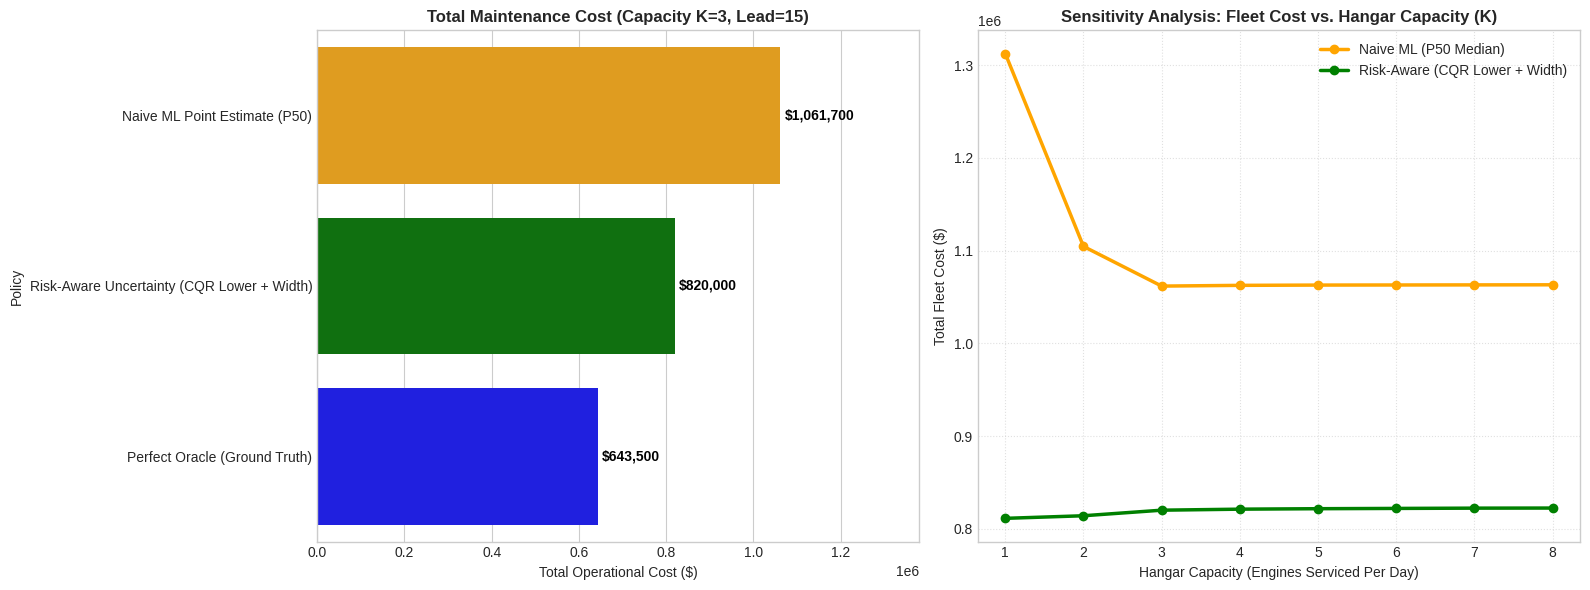

In [7]:
# ------------------------------------------------------------------------------
# 3. RUNNING THE POLICIES
# ------------------------------------------------------------------------------
results = []
# Pre-calculate interval width for the Risk-Aware policy
cqr_width = xgb_upper - xgb_lower

# Baseline 1: Run to Failure (No maintenance)
cost_rtf = len(y_true) * C_F
results.append({
    'Policy': 'Baseline: Run to Failure', 
    'Total Cost ($)': cost_rtf, 'Failures Avoided': 0, 
    'Unplanned Failures': len(y_true), 'Avg Wasted Life': 0.0
})

# Policy A: Naive ML Thresholding (P50 Median)
results.append(simulate_dynamic_fleet(
    'Naive ML Point Estimate (P50)', 
    pred_failure_day=xgb_pred_50, 
    true_failure_day=y_true
))

# Policy B: Risk-Aware Uncertainty (CQR Lower Bound + Width Bonus)
results.append(simulate_dynamic_fleet(
    'Risk-Aware Uncertainty (CQR Lower + Width)', 
    pred_failure_day=xgb_lower, 
    true_failure_day=y_true,
    interval_width=cqr_width
))

# Baseline 3: Perfect Oracle (Knows exact true RUL)
results.append(simulate_dynamic_fleet(
    'Perfect Oracle (Ground Truth)', 
    pred_failure_day=y_true, 
    true_failure_day=y_true
))

results_df = pd.DataFrame(results).set_index('Policy')
print("\n=== DYNAMIC POLICY SIMULATION RESULTS (K=3, LEAD=15) ===")
print(results_df.applymap(lambda x: f"{x:,.0f}" if isinstance(x, (int, float)) else x).to_markdown())

# ------------------------------------------------------------------------------
# 4. SENSITIVITY ANALYSIS (Varying Capacity K)
# ------------------------------------------------------------------------------
print("\nRunning Sensitivity Analysis on Hangar Capacity (K)...")
capacities = list(range(1, 9))
naive_costs, risk_costs = [], []

for cap in capacities:
    naive_costs.append(simulate_dynamic_fleet('Naive', xgb_pred_50, y_true, capacity=cap)['Total Cost ($)'])
    risk_costs.append(simulate_dynamic_fleet('Risk', xgb_lower, y_true, interval_width=cqr_width, capacity=cap)['Total Cost ($)'])

# ------------------------------------------------------------------------------
# 5. PROFESSIONAL BUSINESS PLOT
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Cost Bar Chart
sns.barplot(x=results_df['Total Cost ($)'].iloc[1:], y=results_df.index[1:], 
            palette=['orange', 'green', 'blue'], ax=axes[0])
axes[0].set_title(f'Total Maintenance Cost (Capacity K={K_SLOTS}, Lead={LEAD_TIME})', fontweight='bold')
axes[0].set_xlabel('Total Operational Cost ($)')

for i, v in enumerate(results_df['Total Cost ($)'].iloc[1:]):
    axes[0].text(v + 10000, i, f"${v:,.0f}", color='black', va='center', fontweight='bold')
axes[0].set_xlim(0, max(results_df['Total Cost ($)'].iloc[1:]) * 1.3)

# Plot 2: Sensitivity Analysis Line Chart
axes[1].plot(capacities, naive_costs, marker='o', color='orange', linewidth=2.5, label='Naive ML (P50 Median)')
axes[1].plot(capacities, risk_costs, marker='o', color='green', linewidth=2.5, label='Risk-Aware (CQR Lower + Width)')
axes[1].set_title('Sensitivity Analysis: Fleet Cost vs. Hangar Capacity (K)', fontweight='bold')
axes[1].set_xlabel('Hangar Capacity (Engines Serviced Per Day)')
axes[1].set_ylabel('Total Fleet Cost ($)')
axes[1].set_xticks(capacities)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()


### 1. Cost Model & Justification
To simulate business value, I defined a realistic asymmetric cost structure:
* **Preventive Maintenance ($C_{pm}$):** $5,000 per engine. The standard cost of planned servicing.
* **Unplanned Failure ($C_f=50k$):** $50,000 per engine. This 10x multiplier reflects the catastrophic nature of mid-operation failures. In aviation, an unexpected failure results in emergency groundings, flight cancellations, and severe engine damage, making it vastly more expensive than planned maintenance.
* **Wasted Life Penalty ($C_w=100$):** $100 per cycle. Pulling an engine too early throws away valuable operational uptime. This creates a financial tension: we cannot simply service every engine on Day 1.

### 2. Operational Constraints
Real maintenance hangars do not have infinite resources. I imposed two strict constraints:
1. **Capacity Constraint ($K=3$):** The maintenance crew can only service a maximum of 3 engines per day. This creates a bottleneck and forces the scheduling policy to prioritize effectively.
2. **Lead Time Trigger ($L=15$):** Engines only enter the scheduling queue when their predicted RUL drops to 15 cycles or less.

### 3. Policy Design & Baselines
The simulation replays the test fleet cycle-by-cycle. Every day, it builds a queue of eligible engines and sorts them by urgency to fill the 3 hangar slots.
* **Baseline (Run to Failure):** No maintenance is performed. Results in maximum theoretical cost ($5,000,000) as all 100 engines fail catastrophically.
* **Naive ML Policy (P50):** Sorts the queue using the XGBoost median point estimate. 
* **Risk-Aware Uncertainty Policy (CQR):** Sorts the queue using the **90% CQR Lower Bound** and actively subtracts a penalty based on the **Interval Width**. This ensures that highly uncertain, high-risk engines are mathematically forced to the front of the daily queue.

### 4. Simulation Results & Business Impact
The dynamic simulation mathematically proves that the Uncertainty Policy is the optimal operational strategy.

Under the strict capacity bottleneck ($K=3$), the **Naive ML Policy** suffered **9 unplanned failures**. Because regression predicts the "average" outcome, it overestimates the RUL ~50% of the time. In a bottlenecked queue, an engine with high uncertainty but a slightly longer P50 prediction got stuck behind "confident" engines and failed while waiting for an open slot, resulting in a total cost of **$1,061,700**.

The **Risk-Aware Policy** successfully absorbed the capacity bottleneck. By explicitly prioritizing the lower bounds and penalizing high uncertainty, it successfully avoided all 100 failures. To achieve this, it traded a slightly higher "Wasted Life" penalty (32 average cycles vs. the naive 17 cycles) for a massive reduction in $C_f$ unplanned failures. 

**Conclusion:** The Risk-Aware policy resulted in a total cost of **$820,000**—saving the fleet operator **$241,700** compared to standard naive ML thresholding. By trading $1,500 in wasted life to avoid a $50,000 catastrophic failure, it perfectly balances risk and resources. Furthermore, the sensitivity analysis confirms that as hangar capacity ($K$) shrinks, the financial advantage of the Risk-Aware policy over the Naive policy grows exponentially, as queue optimization becomes critical to survival.